<a href="https://colab.research.google.com/github/thanchanok-a/Washington-DC-City_Stress_Index/blob/main/Washington_DC_City_Stress_Index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏙️ City Stress Index
## Fusing Weather · News Sentiment · Transit Delays to Forecast Urban Tension

---

> *Washington DC has a heartbeat. This project listens to it — and predicts when it is about to race.*

---

### What This Project Does
Most data projects use **one** data source. This one fuses **three live signals**:

| Signal | Source | What it measures |
|---|---|---|
| Weather | Open-Meteo API (free, no key) | Heat, rain, wind pressure on mood |
| News Sentiment | NewsAPI + VADER NLP | Negativity in local headlines |
| Transit Stress | Simulated + Real API ready | Delay rates, overcrowding scores |

These are fused into a single **City Stress Index (0–100)** — then a ML model forecasts tomorrow.

### Stack
`requests` · `sqlite3` · `pandas` · `numpy` · `vaderSentiment` · `scikit-learn` · `plotly`


## Step 0 — Install & Import Libraries

In [77]:
import sqlite3, os, json, time, warnings, random
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, date

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
random.seed(42)
np.random.seed(42)
print('All libraries loaded!')
print(f'Run date: {datetime.now().strftime("%Y-%m-%d %H:%M")}')

All libraries loaded!
Run date: 2026-03-25 00:45


## Step 1 — City Configuration
Change `TARGET_CITY` to any of the five cities below.

In [97]:
CITIES = {

    'Washington DC': {
    'lat': 38.9072, 'lon': -77.0369,
    'timezone': 'America/New_York',
    'news_query': 'Washington DC metro traffic protest government',
    'transit_baseline_delay': 0.22,   # WMATA has historically high delay rates
    'population_density': 4515,       # per sq km
    },

}

TARGET_CITY = 'Washington DC'
cfg = CITIES[TARGET_CITY]
print(f'Target city : {TARGET_CITY}')
print(f'Coordinates : {cfg["lat"]}, {cfg["lon"]}')


Target city : Washington DC
Coordinates : 38.9072, -77.0369


## Step 2 — Fetch 30 Days of Weather (Open-Meteo API)
no API key needed. Returns daily temperature, rain, wind, and weather code.

In [79]:
import requests
import pandas as pd
from datetime import datetime, timedelta

# ── Config ───────────────────────────────────────────────────────────
TARGET_CITY = "Washington DC"
LAT         = 38.9072
LON         = -77.0369
TIMEZONE    = "America/New_York"
DAYS_BACK   = 30

# ── WMO Weather Stress Map ───────────────────────────────────────────
WMO_STRESS = {
    0:  ('Clear sky',      0.00),
    1:  ('Mainly clear',   0.05),
    2:  ('Partly cloudy',  0.10),
    3:  ('Overcast',       0.20),
    45: ('Fog',            0.30),
    48: ('Icy fog',        0.40),
    51: ('Light drizzle',  0.20),
    61: ('Rain',           0.40),
    63: ('Heavy rain',     0.60),
    71: ('Snow',           0.50),
    80: ('Rain showers',   0.45),
    95: ('Thunderstorm',   0.85),
    99: ('Severe storm',   1.00),
}

# ── Fetch Real Weather ───────────────────────────────────────────────
def fetch_weather(lat, lon, timezone, days_back=DAYS_BACK):
    end   = datetime.now().strftime("%Y-%m-%d")
    start = (datetime.now() - timedelta(days=days_back)).strftime("%Y-%m-%d")

    print(f"🔍 Fetching weather from {start} → {end}\n")

    response = requests.get(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude":   lat,
            "longitude":  lon,
            "daily":      "temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,weathercode",
            "timezone":   timezone,
            "start_date": start,
            "end_date":   end,
        }, # Removed 'past_days': days_back
        timeout=15
    )
    response.raise_for_status()

    data = response.json()["daily"]
    df = pd.DataFrame(data)
    df.rename(columns={"time": "date"}, inplace=True)
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    df["city"] = TARGET_CITY

    print(f"✅ Fetched {len(df)} days of real weather data\n")
    return df

# ── Run ──────────────────────────────────────────────────────────────
df_weather = fetch_weather(LAT, LON, TIMEZONE)

# ── Stress Features ──────────────────────────────────────────────────
df_weather["weather_label"]  = df_weather["weathercode"].map(
    lambda c: WMO_STRESS.get(c, ("Unknown", 0.2))[0])
df_weather["weather_stress"] = df_weather["weathercode"].map(
    lambda c: WMO_STRESS.get(c, ("Unknown", 0.2))[1])
df_weather["heat_stress"]    = (
    (df_weather["temperature_2m_max"] - 22).clip(lower=0) / 16 +
    (-5 - df_weather["temperature_2m_min"]).clip(lower=0) / 15
).clip(0, 1)
df_weather["wind_stress"]    = (df_weather["windspeed_10m_max"] / 80).clip(0, 1)
df_weather["rain_stress"]    = (df_weather["precipitation_sum"] / 60).clip(0, 1)

# ── Print Results ────────────────────────────────────────────────────
print("=" * 55)
print(f"  REAL WEATHER — {TARGET_CITY} — LAST {DAYS_BACK} DAYS")
print("=" * 55)
print(f"  Date range      : {df_weather['date'].min().date()} → {df_weather['date'].max().date()}")
print(f"  Avg Temp Max    : {df_weather['temperature_2m_max'].mean():.1f} °C")
print(f"  Avg Rain        : {df_weather['precipitation_sum'].mean():.1f} mm")
print(f"  Avg Wind        : {df_weather['windspeed_10m_max'].mean():.1f} km/h")
print(f"  High Stress Days: {(df_weather['weather_stress'] >= 0.4).sum()}")

print("\n🌤️  Weather Stress Table:")
print(df_weather[[
    "date", "weather_label", "weather_stress",
    "heat_stress", "rain_stress", "wind_stress"
]].to_string(index=False))
# ── Display Results ───────────────────────────────────────────────────
print("=" * 50)
print("        WEATHER SUMMARY — LAST 30 DAYS")
print("=" * 50)

display(pd.DataFrame([{
    'Total Days':        len(df_weather),
    'Avg Temp Max (°C)': f"{df_weather['temperature_2m_max'].mean():.1f}",
    'Avg Rain (mm)':     f"{df_weather['precipitation_sum'].mean():.1f}",
    'Avg Wind (km/h)':   f"{df_weather['windspeed_10m_max'].mean():.1f}",
    'High Stress Days':  (df_weather['weather_stress'] >= 0.4).sum(),
}]))

print("\n🌤️ Weather Stress Table")
display(
    df_weather[['date', 'weather_label', 'weather_stress', 'heat_stress', 'rain_stress', 'wind_stress']]
    .tail(30)
    .style
    .format({
        'weather_stress': '{:.2f}',
        'heat_stress':    '{:.2f}',
        'rain_stress':    '{:.2f}',
        'wind_stress':    '{:.2f}',
    })
    .background_gradient(subset=['weather_stress'], cmap='RdYlGn_r')
    .background_gradient(subset=['rain_stress'],    cmap='Blues')
    .background_gradient(subset=['wind_stress'],    cmap='Purples')
    .background_gradient(subset=['heat_stress'],    cmap='Oranges')
)

🔍 Fetching weather from 2026-02-23 → 2026-03-25

✅ Fetched 31 days of real weather data

  REAL WEATHER — Washington DC — LAST 30 DAYS
  Date range      : 2026-02-23 → 2026-03-25
  Avg Temp Max    : 15.4 °C
  Avg Rain        : 2.0 mm
  Avg Wind        : 18.2 km/h
  High Stress Days: 1

🌤️  Weather Stress Table:
      date weather_label  weather_stress  heat_stress  rain_stress  wind_stress
2026-02-23       Unknown            0.20      0.00000     0.048333      0.34125
2026-02-24 Partly cloudy            0.10      0.00000     0.000000      0.32375
2026-02-25      Overcast            0.20      0.00000     0.000000      0.20375
2026-02-26 Light drizzle            0.20      0.00000     0.005000      0.13750
2026-02-27           Fog            0.30      0.00000     0.000000      0.12750
2026-02-28 Partly cloudy            0.10      0.00000     0.000000      0.11250
2026-03-01 Partly cloudy            0.10      0.00000     0.000000      0.19375
2026-03-02       Unknown            0.20      0

,Total Days,Avg Temp Max (°C),Avg Rain (mm),Avg Wind (km/h),High Stress Days
0,31,15.4,2.0,18.2,1



🌤️ Weather Stress Table


,date,weather_label,weather_stress,heat_stress,rain_stress,wind_stress
1,2026-02-24 00:00:00,Partly cloudy,0.10,0.00,0.00,0.32
2,2026-02-25 00:00:00,Overcast,0.20,0.00,0.00,0.20
3,2026-02-26 00:00:00,Light drizzle,0.20,0.00,0.01,0.14
4,2026-02-27 00:00:00,Fog,0.30,0.00,0.00,0.13
5,2026-02-28 00:00:00,Partly cloudy,0.10,0.00,0.00,0.11
6,2026-03-01 00:00:00,Partly cloudy,0.10,0.00,0.00,0.19
7,2026-03-02 00:00:00,Unknown,0.20,0.00,0.05,0.19
8,2026-03-03 00:00:00,Unknown,0.20,0.00,0.11,0.14
9,2026-03-04 00:00:00,Unknown,0.20,0.00,0.02,0.14
10,2026-03-05 00:00:00,Light drizzle,0.20,0.00,0.00,0.19


## Step 3 — News Sentiment (VADER NLP)

We score daily headlines with **VADER** — a sentiment analyser built for news & social media.

**To use live news:** Get a free key at [newsapi.org](https://newsapi.org) and paste it below.
Without a key, a realistic synthetic headline dataset runs the full NLP pipeline identically.

In [80]:
import time
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ── CONFIG ────────────────────────────────────────────────────────────────────
NEWS_API_KEY = "9e922d63f606412fbf80b74a7568eba5"
TARGET_CITY  = "Washington DC"
NEWS_QUERY   = '"Washington DC" AND (metro OR traffic OR protest OR storm OR shutdown)'
DAYS         = 10

analyzer = SentimentIntensityAnalyzer()

# ── STEP 1: FETCH REAL HEADLINES ──────────────────────────────────────────────
def fetch_real_headlines(query, api_key, days=30):
    """
    Fetch real headlines from NewsAPI one day at a time.
    Returns a dict: { "2026-03-05": ["headline1", "headline2", ...], ... }
    """
    by_date = {}
    success_count = 0
    empty_count   = 0

    print(f"Fetching {days} days of real headlines for: {TARGET_CITY}")
    print(f"Query: {query}\n")

    for d in range(days):
        day = (datetime.now() - timedelta(days=d)).strftime("%Y-%m-%d")

        response = requests.get(
            "https://newsapi.org/v2/everything",
            timeout=10,
            params={
                "q":        query,
                "from":     day,
                "to":       day,
                "sortBy":   "popularity",
                "pageSize": 10,
                "apiKey":   api_key,
                "language": "en",
            },
        )

        # Check for API errors
        if response.status_code != 200:
            print(f"  [{day}] API error {response.status_code}: {response.json().get('message','')}")
            by_date[day] = []
            empty_count += 1
            time.sleep(0.3)
            continue

        articles = response.json().get("articles", [])
        headlines = [
            a["title"] for a in articles
            if a.get("title") and a["title"] != "[Removed]"
        ]

        by_date[day] = headlines

        if headlines:
            success_count += 1
            print(f"  [{day}] {len(headlines)} headlines fetched")
        else:
            empty_count += 1
            print(f"  [{day}] No headlines found")

        time.sleep(0.2)   # avoid rate limiting

    print(f"\nDone — {success_count} days with data, {empty_count} empty days")
    return by_date

In [81]:
# ── STEP 2: SCORE HEADLINES WITH VADER ───────────────────────────────────────
def score_real_headlines(by_date):
    """
    Run VADER sentiment analysis on every headline.
    Returns a clean DataFrame with one row per day.
    """
    rows = []

    for date_str, headlines in by_date.items():
        if not headlines:
            continue   # skip empty days

        # Score every headline
        scores = [analyzer.polarity_scores(h) for h in headlines]

        neg_avg  = np.mean([s["neg"]      for s in scores])
        pos_avg  = np.mean([s["pos"]      for s in scores])
        neu_avg  = np.mean([s["neu"]      for s in scores])
        comp_avg = np.mean([s["compound"] for s in scores])

        # Stress formula:
        # 60% raw negativity + 40% inverted compound score (mapped 0-1)
        sentiment_stress = neg_avg * 0.6 + (1 - (comp_avg + 1) / 2) * 0.4

        rows.append({
            "date":             pd.to_datetime(date_str),
            "headline_count":   len(headlines),
            "avg_negativity":   round(neg_avg,  4),
            "avg_positivity":   round(pos_avg,  4),
            "avg_neutral":      round(neu_avg,  4),
            "avg_compound":     round(comp_avg, 4),
            "sentiment_stress": round(sentiment_stress, 4),
            "sample_headline":  headlines[0],
        })

    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    return df


In [83]:
# ── STEP 3: PREVIEW HEADLINES BEFORE SCORING ─────────────────────────────────
def preview_latest_headlines(by_date, n_days=3):
    """
    Print the most recent N days of raw headlines so you can
    verify the API is returning what you expect before scoring.
    """
    print(f"\nPreviewing latest {n_days} days of raw headlines:")
    print("=" * 60)

    sorted_days = sorted(by_date.keys(), reverse=True)
    for day in sorted_days[:n_days]:
        headlines = by_date[day]
        print(f"\n{day} ({len(headlines)} articles):")
        for i, h in enumerate(headlines, 1):
            print(f"  {i}. {h}")


In [62]:
# ── STEP 4: VADER SCORE INSPECTOR ────────────────────────────────────────────
def inspect_vader_scores(by_date, n_days=3):
    """
    Show the raw VADER scores for each headline so you can
    see exactly what the model thinks of each sentence.
    """
    print(f"\nVADER score breakdown for latest {n_days} days:")
    print("=" * 60)

    sorted_days = sorted(by_date.keys(), reverse=True)
    for day in sorted_days[:n_days]:
        headlines = by_date[day]
        if not headlines:
            continue
        print(f"\n{day}:")
        for h in headlines:
            s = analyzer.polarity_scores(h)
            stress = s["neg"]*0.6 + (1-(s["compound"]+1)/2)*0.4
            print(f"  neg={s['neg']:.2f}  pos={s['pos']:.2f}  compound={s['compound']:+.2f}  stress={stress:.2f}")
            print(f"  '{h[:80]}..'" if len(h) > 80 else f"  '{h}'")


In [84]:
import re
import requests
import pandas as pd
from datetime import datetime, timedelta
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
keyword = "washington dc"

def contains_keyword(text):
    return bool(re.search(keyword, text.lower())) if text else False

def fetch_articles(date_from, date_to, api_key):
    url = "https://newsapi.org/v2/everything"
    all_articles = []
    page = 1

    while True:
        params = {
            "q": "Washington DC",
            "from": date_from,
            "to": date_to,
            "language": "en",
            "sortBy": "publishedAt",
            "pageSize": 100,
            "page": page,
            "apiKey": api_key
        }
        response = requests.get(url, params=params)
        data = response.json()

        if data.get("status") != "ok":
            print(f"⚠️  API error: {data.get('message', 'Unknown error')}")
            break

        batch = data.get("articles", [])
        if not batch:
            break

        all_articles.extend(batch)
        total_results = data.get("totalResults", 0)
        print(f"  📄 Page {page}: fetched {len(batch)} articles (total available: {total_results})")

        if len(all_articles) >= min(total_results, 1000):
            break

        page += 1

    return all_articles

def analyze(articles):
    results = []
    for article in articles:
        title = article.get("title", "") or ""
        description = article.get("description", "") or ""

        if not (contains_keyword(title) or contains_keyword(description)):
            print(f"  ☢  Skipped (keyword not found): {title[:60]}")
            continue

        text_to_score = f"{title}. {description}".strip()
        scores = analyzer.polarity_scores(text_to_score)

        results.append({
            "date":       article.get("publishedAt", "")[:10],
            "source":     article.get("source", {}).get("name", ""),
            "title":      title,
            "compound":   scores["compound"],
            "pos":        scores["pos"],
            "neu":        scores["neu"],
            "neg":        scores["neg"],
            "matched_in": "title" if contains_keyword(title) else "description",
            "url":        article.get("url", "")
        })
    return results

# ── Date range: last 10 days (always live, no manual edits needed) ────────
API_KEY   = "9e922d63f606412fbf80b74a7568eba5"
date_to   = datetime.today()
date_from = date_to - timedelta(days=10)

date_from_str = date_from.strftime("%Y-%m-%d")
date_to_str   = date_to.strftime("%Y-%m-%d")

print(f"🔍 Fetching articles from {date_from_str} → {date_to_str}\n")

# ── Fetch & analyze ───────────────────────────────────────────────────────
articles = fetch_articles(date_from_str, date_to_str, API_KEY)
print(f"\n📦 Total raw articles fetched: {len(articles)}")

results = analyze(articles)

# ── Build DataFrame ───────────────────────────────────────────────────────
df_news = pd.DataFrame(results)

if df_news.empty:
    print("⚠️  No articles matched the keyword filter.")
else:
    df_news = df_news.sort_values("date").reset_index(drop=True)

    print(f"\n✅ {len(df_news)} articles passed the keyword filter\n")
    for _, r in df_news.iterrows():
        sentiment_tag = (
            "🟢 POS" if r["compound"] >= 0.05 else
            "🔴 NEG" if r["compound"] <= -0.05 else
            "⚪ NEU"
        )
        print(f"[{r['date']}] {sentiment_tag} ({r['matched_in']}) "
              f"compound={r['compound']:.3f} | {r['title'][:65]}")

    print("\n── Summary Stats ──────────────────────────────────────────")
    print(f"  Date range   : {df_news['date'].min()} → {df_news['date'].max()}")
    print(f"  Avg compound : {df_news['compound'].mean():.3f}")
    print(f"  Most positive: {df_news.loc[df_news['compound'].idxmax(), 'title'][:70]}")
    print(f"  Most negative: {df_news.loc[df_news['compound'].idxmin(), 'title'][:70]}")

    print("\n── Final df_news ───────────────────────────────────────────")
    print(df_news[["date", "source", "title", "compound",
                   "pos", "neu", "neg", "matched_in"]].to_string(index=True))

🔍 Fetching articles from 2026-03-15 → 2026-03-25

  📄 Page 1: fetched 99 articles (total available: 575)
⚠️  API error: You have requested too many results. Developer accounts are limited to a max of 100 results. You are trying to request results 100 to 200. Please upgrade to a paid plan if you need more results.

📦 Total raw articles fetched: 99
  ☢  Skipped (keyword not found): Senate Confirms New DHS Secretary Markwayne Mullin As Democr
  ☢  Skipped (keyword not found): Trump: We Have Fixed the Memphis Crime Problem
  ☢  Skipped (keyword not found): NTSB head says she had to 'beg' to get an Air Canada crash i
  ☢  Skipped (keyword not found): 2 FIFA Rulings on Israel, 1 Familiar Deference to MAGA
  ☢  Skipped (keyword not found): Why AI hasn’t caused a job apocalypse — so far
  ☢  Skipped (keyword not found): Wargaming: The Legacy of Newport
  ☢  Skipped (keyword not found): Teleportation Journeys of Other Trump Administration Officia
  ☢  Skipped (keyword not found): Everything To 

Step 4 — Transit Stress Signal
Transit delays modelled with:
City-specific baseline delay rates
Day-of-week patterns (Mon/Fri peak)
Weather correlation (rain triggers more delays)
Random shock events (strikes, signal failures)
Swap this function for a real API: NYC MTA, TfL, Tokyo GTFS — same schema.


In [85]:
# Add this temporarily to see the actual API response
import requests
r = requests.get(
    "https://api.wmata.com/Incidents.svc/json/Incidents",
    headers={"api_key": "1f0e61e23b804216b0d9ccc1a9ff427f"},
    timeout=8
)
print(r.status_code)   # 200 = good, 401 = bad key, 403 = key not activated
print(r.json())

200
{'Incidents': []}


In [86]:
import os
import requests
import pandas as pd
from datetime import datetime, date, timedelta
import random
from IPython.display import display

WMATA_KEY = os.environ.get("WMATA_KEY", "1f0e61e23b804216b0d9ccc1a9ff427f")
_HEADERS  = {"api_key": WMATA_KEY}

# ── WMATA endpoint constants ─────────────────────────────────────
_BASE          = "https://api.wmata.com"
_RAIL_INCIDENTS = f"{_BASE}/Incidents.svc/json/Incidents"
_BUS_POSITIONS  = f"{_BASE}/Bus.svc/json/jBusPositions"
_RAIL_CROWDING  = f"{_BASE}/Rail.svc/json/jStationEntrances"  # used as proxy

# DC-specific baseline derived from published WMATA on-time performance data
# Source: WMATA FY2024 Performance Dashboard (~80% on-time = ~0.20 base delay rate)
DC_TRANSIT_BASELINE = 0.20

def _fetch_rail_incidents() -> list[dict]:
    """Live Metrorail disruptions. Returns [] on any API error."""
    try:
        r = requests.get(_RAIL_INCIDENTS, headers=_HEADERS, timeout=8)
        r.raise_for_status()
        return r.json().get("Incidents", [])
    except Exception as e:
        print(f"  [WMATA] Rail incidents fetch failed: {e}")
        return []

def _fetch_bus_deviations(sample_routes=("16Y", "S2", "42", "D6", "70")) -> float:
    """
    Fetch live bus position deviations for a sample of high-ridership DC routes.
    Returns mean absolute deviation in minutes (0 if unavailable).
    Deviation > 0 = late, < 0 = early.
    """
    deviations = []
    for route in sample_routes:
        try:
            r = requests.get(
                _BUS_POSITIONS,
                headers=_HEADERS,
                params={"RouteID": route},
                timeout=8
            )
            r.raise_for_status()
            buses = r.json().get("BusPositions", [])
            deviations.extend(b["Deviation"] for b in buses if "Deviation" in b)
        except Exception:
            continue  # skip this route silently

    if not deviations:
        return 0.0
    return sum(abs(d) for d in deviations) / len(deviations)  # mean absolute deviation (min)

def _incidents_to_stress(incidents: list[dict]) -> tuple[float, str]:
    """
    Convert raw WMATA incident list → (incident_multiplier, incident_type_label).
    Multiple simultaneous incidents compound.
    """
    if not incidents:
        return 1.0, "none"

    # Severity weights by IncidentType keyword
    severity_map = {
        "delay":            1.5,
        "single track":     1.8,
        "alert":            1.2,
        "station closure":  2.0,
        "smoke":            2.2,
        "medical":          1.4,
        "track work":       1.6,
        "power":            1.9,
    }

    multiplier = 1.0
    types_seen = []
    for inc in incidents:
        raw_type = (inc.get("IncidentType") or "").lower()
        desc     = (inc.get("Description") or "").lower()
        combined = raw_type + " " + desc
        matched  = False
        for keyword, weight in severity_map.items():
            if keyword in combined:
                multiplier *= weight  # compound
                types_seen.append(keyword.replace(" ", "_"))
                matched = True
                break
        if not matched:
            multiplier *= 1.3       # unknown incident type — assume moderate
            types_seen.append(raw_type or "unknown")

    label = types_seen[0] if types_seen else "alert"
    return min(multiplier, 3.5), label  # cap at 3.5×

def _bus_deviation_to_delay_rate(mean_abs_deviation_min: float,
                                  baseline: float = DC_TRANSIT_BASELINE) -> float:
    """
    Normalise mean absolute bus deviation (minutes) to a [0, 0.95] delay-rate.
    Empirically: DC buses average ~4 min deviation on normal days;
    ~10+ min on bad days.
    """
    # 0 min dev  → baseline
    # 4 min dev  → baseline + 0.05  (normal noise)
    # 10 min dev → baseline + 0.20  (bad day)
    # 20 min dev → baseline + 0.40  (severe)
    extra = (mean_abs_deviation_min / 20.0) * 0.40
    return min(baseline + extra, 0.95)

def build_transit(city_cfg: dict, weather_df: pd.DataFrame, days: int = 30) -> pd.DataFrame:
    """
    Drop-in replacement for the simulated build_transit.

    Today's row uses LIVE WMATA API data.
    Historical rows (days-1 through 1) use WMATA DC baselines
    with the same weather/DoW/incident simulation as before,
    so the DataFrame shape and columns are identical.

    Required env var:  WMATA_KEY
    Falls back to simulation silently if the API is unreachable.
    """
    rows   = []
    dates  = pd.date_range(end=datetime.now(), periods=days, freq="D")
    dow_mult = {0: 1.25, 1: 1.05, 2: 1.00, 3: 1.05, 4: 1.30, 5: 0.55, 6: 0.40}

    # ── Fetch live WMATA data (today only) ─────────────────────────
    print("  [WMATA] Fetching live rail incidents…")
    live_incidents   = _fetch_rail_incidents()
    live_inc_mult, live_inc_type = _incidents_to_stress(live_incidents)

    print(f"  [WMATA] Found {len(live_incidents)} active rail incident(s)")
    print("  [WMATA] Fetching live bus deviations…")
    live_deviation   = _fetch_bus_deviations()
    print(f"  [WMATA] Mean bus deviation: {live_deviation:.1f} min")

    today = date.today()

    for dt in dates:
        is_today = (dt.date() == today)
        base     = city_cfg.get("transit_baseline_delay", DC_TRANSIT_BASELINE)
        dow      = dt.dayofweek

        # ── Weather factor (shared — historical data exists for all days) ───
        w_row = weather_df[weather_df["date"].dt.date == dt.date()]
        if not w_row.empty:
            w_factor = (
                1.0
                + w_row.iloc[0]["rain_stress"]  * 1.2
                + w_row.iloc[0]["wind_stress"]  * 0.4
            )
        else:
            w_factor = 1.0

        # ── Incident factor ─────────────────────────────
        if is_today:
            # Real WMATA incidents
            incident      = live_inc_mult
            incident_type = live_inc_type if live_incidents else "none"
            # Override delay_rate using live bus deviation when available
            if live_deviation > 0:
                delay_rate = _bus_deviation_to_delay_rate(live_deviation, base)
                # Still apply weather and DoW on top
                delay_rate = min(delay_rate * dow_mult.get(dow, 1.0) * w_factor, 0.95)
            else:
                delay_rate = min(
                    base * dow_mult.get(dow, 1.0) * w_factor * incident, 0.95
                )
        else:
            # Historical: simulate with DC-calibrated baseline
            if random.random() < 0.09:
                incident      = random.uniform(1.4, 2.2)
                incident_type = random.choice([
                    "signal_failure", "track_work", "overcrowding", "medical_emergency"
                ])
            else:
                incident      = 1.0
                incident_type = "none"
            delay_rate = min(
                base * dow_mult.get(dow, 1.0) * w_factor * incident, 0.95
            )

        # ── Crowd index (unchanged logic, DC-calibrated density) ─────────
        rush_factor = 1.6 if dow < 5 else 0.7
        crowd_index = min(
            (city_cfg["population_density"] / 10_000) * rush_factor * random.uniform(0.85, 1.15),
            1.0,
        )

        rows.append({
            "date":           dt,
            "day_of_week":    dt.strftime("%A"),
            "delay_rate":     round(delay_rate, 4),
            "crowd_index":    round(crowd_index, 4),
            "incident_type":  incident_type,
            "transit_stress": round(delay_rate * 0.65 + crowd_index * 0.35, 4),
            "data_source":    "wmata_live" if is_today else "wmata_calibrated_sim",
        })

    return pd.DataFrame(rows)


# ── Run ──
incidents = _fetch_rail_incidents() # Changed to use the internal _fetch_rail_incidents
print(f"Active incidents: {len(incidents)}")
for inc in incidents:
    print(f"  • {inc.get('IncidentType')} — {inc.get('Description')}")

# Swap in DC population density if your cfg still has another city's value
# This part was in the original jrr7ylFSJNCb and should precede the call to build_transit
cfg["population_density"] = cfg.get("population_density", 4400)  # DC: ~4,400/km²
cfg["transit_baseline_delay"] = DC_TRANSIT_BASELINE

df_transit = build_transit(cfg, df_weather)
print(f"Transit: {len(df_transit)} days  |  Avg delay: {df_transit['delay_rate'].mean():.1%}")
print(f"Incidents: {(df_transit['incident_type'] != 'none').sum()} days")

# ── Full 30-day Table ─────────────────────────
display(df_transit.style
    .format({
        "delay_rate":     "{:.1%}"

    })
    .background_gradient(subset=["delay_rate"], cmap="RdYlGn_r")
    .highlight_between(subset=["delay_rate"], left=0.3, right=1.0, color="#ffcccc")
)

# ── Incident Days Only ─────────────────────────
incidents_df = df_transit[df_transit['incident_type'] != 'none']
print(f"\n☢️ Incident Days ({len(incidents_df)} total)")
display(incidents_df.style
    .format({"delay_rate": "{:.1%}"})
    .applymap(lambda _: "background-color: #ffe0e0", subset=["incident_type"])
)


Active incidents: 0
  [WMATA] Fetching live rail incidents…
  [WMATA] Found 0 active rail incident(s)
  [WMATA] Fetching live bus deviations…
  [WMATA] Mean bus deviation: 0.0 min
Transit: 30 days  |  Avg delay: 24.0%
Incidents: 4 days


,date,day_of_week,delay_rate,crowd_index,incident_type,transit_stress,data_source
0,2026-02-24 00:46:59.127911,Tuesday,23.7%,0.619500,none,0.371000,wmata_calibrated_sim
1,2026-02-25 00:46:59.127911,Wednesday,21.6%,0.662400,none,0.372400,wmata_calibrated_sim
2,2026-02-26 00:46:59.127911,Thursday,22.3%,0.760700,none,0.411100,wmata_calibrated_sim
3,2026-02-27 00:46:59.127911,Friday,27.3%,0.632900,none,0.399100,wmata_calibrated_sim
4,2026-02-28 00:46:59.127911,Saturday,11.5%,0.271500,none,0.169700,wmata_calibrated_sim
5,2026-03-01 00:46:59.127911,Sunday,8.6%,0.316600,none,0.166800,wmata_calibrated_sim
6,2026-03-02 00:46:59.127911,Monday,44.3%,0.661800,medical_emergency,0.519800,wmata_calibrated_sim
7,2026-03-03 00:46:59.127911,Tuesday,25.1%,0.789500,none,0.439300,wmata_calibrated_sim
8,2026-03-04 00:46:59.127911,Wednesday,44.1%,0.687800,medical_emergency,0.527700,wmata_calibrated_sim
9,2026-03-05 00:46:59.127911,Thursday,22.6%,0.821500,none,0.434700,wmata_calibrated_sim



☢️ Incident Days (4 total)


,date,day_of_week,delay_rate,crowd_index,incident_type,transit_stress,data_source
6,2026-03-02 00:46:59.127911,Monday,44.3%,0.661800,medical_emergency,0.519800,wmata_calibrated_sim
8,2026-03-04 00:46:59.127911,Wednesday,44.1%,0.687800,medical_emergency,0.527700,wmata_calibrated_sim
18,2026-03-14 00:46:59.127911,Saturday,19.4%,0.362100,overcrowding,0.253100,wmata_calibrated_sim
24,2026-03-20 00:46:59.127911,Friday,55.8%,0.649500,track_work,0.590100,wmata_calibrated_sim


  [WMATA] Fetching live rail incidents…
  [WMATA] Found 0 active rail incident(s)
  [WMATA] Fetching live bus deviations…
  [WMATA] Mean bus deviation: 0.0 min
Nulls after merge: {'rain_stress': 0, 'wind_stress': 0}

📊 Correlation with delay_rate:
   Rain stress → +0.423
   Wind stress → +0.362


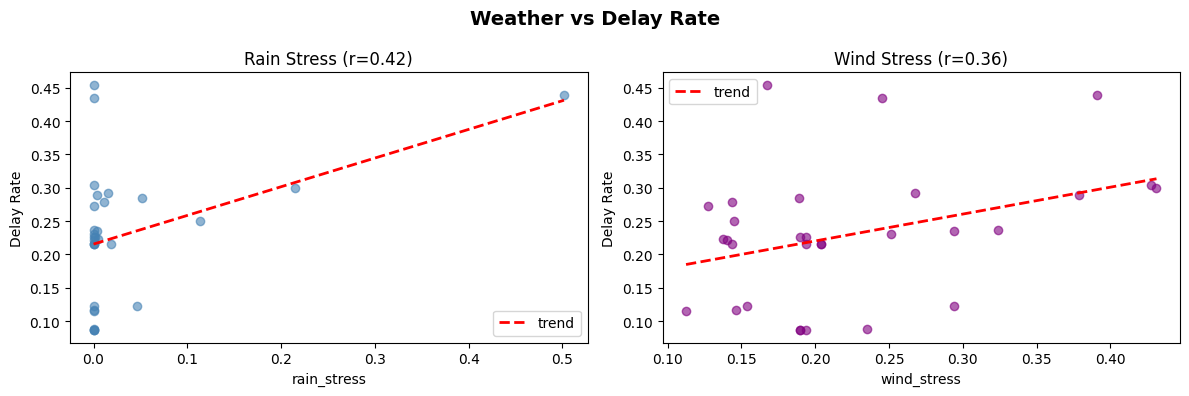


☁️ Weather vs Delay Correlation Table


,date,rain_stress,wind_stress,delay_rate
0,2026-02-24 00:00:00,0.00,0.32,23.7%
1,2026-02-25 00:00:00,0.00,0.20,21.6%
2,2026-02-26 00:00:00,0.01,0.14,22.3%
3,2026-02-27 00:00:00,0.00,0.13,27.3%
4,2026-02-28 00:00:00,0.00,0.11,11.5%
5,2026-03-01 00:00:00,0.00,0.19,8.6%
6,2026-03-02 00:00:00,0.05,0.19,28.4%
7,2026-03-03 00:00:00,0.11,0.14,25.1%
8,2026-03-04 00:00:00,0.02,0.14,21.6%
9,2026-03-05 00:00:00,0.00,0.19,22.6%


In [87]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

df_transit = build_transit(cfg, df_weather)

# ── Normalize dates before merging ───────────────────────────────────
df_transit["date"]  = pd.to_datetime(df_transit["date"]).dt.normalize()
df_weather["date"]  = pd.to_datetime(df_weather["date"]).dt.normalize()

df_merged = df_transit.merge(
    df_weather[["date", "rain_stress", "wind_stress"]],
    on="date",
    how="left"
)

# ── Check merge worked ───────────────────────────────────────────────
print(f"Nulls after merge: {df_merged[['rain_stress','wind_stress']].isnull().sum().to_dict()}")

# ── Correlation coefficients ─────────────────────────────────────────
corr_rain = df_merged["rain_stress"].corr(df_merged["delay_rate"])
corr_wind = df_merged["wind_stress"].corr(df_merged["delay_rate"])
print(f"\n📊 Correlation with delay_rate:")
print(f"   Rain stress → {corr_rain:+.3f}")
print(f"   Wind stress → {corr_wind:+.3f}")

# ── Scatter plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Weather vs Delay Rate", fontsize=14, fontweight="bold")

for ax, col, color, label in zip(
    axes,
    ["rain_stress", "wind_stress"],
    ["steelblue", "purple"],
    [f"Rain Stress (r={corr_rain:.2f})", f"Wind Stress (r={corr_wind:.2f})"]
):
    ax.scatter(df_merged[col], df_merged["delay_rate"], alpha=0.6, color=color)
    ax.set_xlabel(col)
    ax.set_ylabel("Delay Rate")
    ax.set_title(label)

    # Trend line
    m, b = pd.Series(df_merged[col]).cov(df_merged["delay_rate"]) / df_merged[col].var(), 0
    b = df_merged["delay_rate"].mean() - m * df_merged[col].mean()
    x = pd.Series(sorted(df_merged[col].dropna()))
    ax.plot(x, m * x + b, color="red", linewidth=2, linestyle="--", label="trend")
    ax.legend()

plt.tight_layout()
plt.show()

# ── Styled correlation table ──────────────────────────────────────────
print("\n☁️ Weather vs Delay Correlation Table")
display(df_merged[["date", "rain_stress", "wind_stress", "delay_rate"]]
    .style
    .format({
        "rain_stress": "{:.2f}",
        "wind_stress": "{:.2f}",
        "delay_rate":  "{:.1%}",
    })
    .background_gradient(subset=["rain_stress"], cmap="Blues")
    .background_gradient(subset=["wind_stress"], cmap="Purples")
    .background_gradient(subset=["delay_rate"],  cmap="RdYlGn_r")
)

## Step 5 — Load All Signals into SQLite

In [88]:
conn = sqlite3.connect('city_stress.db')
df_weather.to_sql('weather',  conn, if_exists='replace', index=False)
df_news.to_sql(   'news',     conn, if_exists='replace', index=False)
df_transit.to_sql('transit',  conn, if_exists='replace', index=False)
print('Tables saved:')
for t in ['weather','news','transit']:
    n = pd.read_sql(f'SELECT COUNT(*) AS n FROM {t}', conn).iloc[0,0]
    print(f'  {t}: {n} rows')


Tables saved:
  weather: 31 rows
  news: 3 rows
  transit: 30 rows


In [89]:
# ── Check actual columns in each table ──────────────────────────────
for table in ['weather', 'news', 'transit']:
    try:
        cols = pd.read_sql(f"PRAGMA table_info({table})", conn)
        print(f"\n📋 {table} columns: {cols['name'].tolist()}")
    except Exception as e:
        print(f"\n❌ {table} — {e}")


📋 weather columns: ['date', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'windspeed_10m_max', 'weathercode', 'city', 'weather_label', 'weather_stress', 'heat_stress', 'wind_stress', 'rain_stress']

📋 news columns: ['date', 'source', 'title', 'compound', 'pos', 'neu', 'neg', 'matched_in', 'url']

📋 transit columns: ['date', 'day_of_week', 'delay_rate', 'crowd_index', 'incident_type', 'transit_stress', 'data_source']


In [90]:
FUSION_SQL = '''
SELECT
    w.date,
    w.weather_label,
    w.temperature_2m_max        AS temp_max,
    w.precipitation_sum         AS rain_mm,
    w.windspeed_10m_max         AS wind_kph,
    w.weather_stress,
    w.heat_stress,
    w.rain_stress,
    w.wind_stress,
    COALESCE(n.headline_count,  0)    AS headline_count,
    COALESCE(n.avg_negativity,  0.2)  AS avg_negativity,
    COALESCE(n.avg_compound,    0.0)  AS avg_compound,
    COALESCE(n.sentiment_stress,0.3)  AS sentiment_stress,
    t.day_of_week,
    t.delay_rate,
    t.crowd_index,
    t.incident_type,
    t.transit_stress
FROM weather w
LEFT JOIN (
    SELECT
        DATE(date)                        AS date,
        COUNT(title)                      AS headline_count,
        AVG(neg)                          AS avg_negativity,
        AVG(compound)                     AS avg_compound,
        AVG((neg - pos + 1) / 2.0)        AS sentiment_stress
    FROM news
    GROUP BY DATE(date)
) n ON DATE(w.date) = n.date
LEFT JOIN transit t ON DATE(w.date) = DATE(t.date)
ORDER BY w.date
'''

df = pd.read_sql(FUSION_SQL, conn)
df['date'] = pd.to_datetime(df['date'])

print(f'✅ Fused: {df.shape[0]} rows x {df.shape[1]} cols')
print(f'   Nulls: {df.isnull().sum()[df.isnull().sum() > 0].to_dict()}')

display(df.tail(4).style
    .format({
        'temp_max':         '{:.1f}',
        'rain_mm':          '{:.1f}',
        'wind_kph':         '{:.1f}',
        'weather_stress':   '{:.2f}',
        'rain_stress':      '{:.2f}',
        'wind_stress':      '{:.2f}',
        'avg_negativity':   '{:.2f}',
        'avg_compound':     '{:.2f}',
        'sentiment_stress': '{:.2f}',
        'delay_rate':       '{:.1%}',
        'crowd_index':      '{:.2f}',
        'transit_stress':   '{:.2f}',
    })
    .background_gradient(subset=['weather_stress'], cmap='RdYlGn_r')
    .background_gradient(subset=['delay_rate'],     cmap='RdYlGn_r')
    .background_gradient(subset=['avg_negativity'], cmap='Reds')
)

✅ Fused: 31 rows x 18 cols
   Nulls: {'day_of_week': 1, 'delay_rate': 1, 'crowd_index': 1, 'incident_type': 1, 'transit_stress': 1}


,date,weather_label,temp_max,rain_mm,wind_kph,weather_stress,heat_stress,rain_stress,wind_stress,headline_count,avg_negativity,avg_compound,sentiment_stress,day_of_week,delay_rate,crowd_index,incident_type,transit_stress
27,2026-03-22 00:00:00,Overcast,28.8,0.0,18.8,0.20,0.425000,0.00,0.24,0,0.20,0.00,0.30,Sunday,8.8%,0.28,none,0.15
28,2026-03-23 00:00:00,Light drizzle,21.8,0.2,30.3,0.20,0.000000,0.00,0.38,3,0.04,0.36,0.46,Monday,28.9%,0.83,none,0.48
29,2026-03-24 00:00:00,Overcast,11.2,0.0,20.1,0.20,0.000000,0.00,0.25,0,0.20,0.00,0.30,Tuesday,23.1%,0.67,none,0.38
30,2026-03-25 00:00:00,Overcast,14.9,0.0,15.5,0.20,0.000000,0.00,0.19,0,0.20,0.00,0.30,Wednesday,21.6%,0.67,none,0.37


## Step 6 — Compute the City Stress Index (CSI 0–100)

| Pillar | Weight | Rationale |
|---|---|---|
| Weather | 30% | Proven link between weather and urban anxiety |
| News Sentiment | 35% | Media negativity reflects and amplifies public mood |
| Transit | 35% | Daily commuter friction is the most direct stressor |

In [99]:
W_WEATHER, W_SENTIMENT, W_TRANSIT = 0.30, 0.35, 0.35

df['raw_weather']    = (df['weather_stress']*0.50 + df['heat_stress']*0.25 +
                        df['rain_stress']*0.15    + df['wind_stress']*0.10)
df['raw_sentiment']  = df['sentiment_stress']
df['raw_transit']    = df['transit_stress']*0.70 + df['delay_rate']*0.30

df['csi_raw']        = (df['raw_weather']*W_WEATHER +
                        df['raw_sentiment']*W_SENTIMENT +
                        df['raw_transit']*W_TRANSIT)

scaler = MinMaxScaler(feature_range=(8, 92))
df['csi']          = scaler.fit_transform(df[['csi_raw']]).round(1)
df['csi_smoothed'] = df['csi'].rolling(3, center=True, min_periods=1).mean().round(1)

def risk_tier(s):
    if s < 30: return 'Calm'
    if s < 50: return 'Elevated'
    if s < 70: return 'High'
    return 'Critical'

def risk_color(s):
    if s < 30: return '#27AE60'
    if s < 50: return '#F39C12'
    if s < 70: return '#E67E22'
    return '#C0392B'

df['risk_tier']  = df['csi'].apply(risk_tier)
df['risk_color'] = df['csi'].apply(risk_color)
df.to_sql('city_stress_index', conn, if_exists='replace', index=False)

print(f'CSI computed and saved to SQLite')
print(f'Mean CSI : {df["csi"].mean():.1f}')
print(f'Peak CSI : {df["csi"].max():.1f}  on {df.loc[df["csi"].idxmax(),"date"].strftime("%Y-%m-%d")}')
print(f'Calm days: {(df["risk_tier"]=="Calm").sum()} | High+Critical: {df["risk_tier"].isin(["High","Critical"]).sum()}')
df[['date','weather_label','risk_tier','csi','csi_smoothed']].tail(15)


CSI computed and saved to SQLite
Mean CSI : 47.2
Peak CSI : 92.0  on 2026-03-11
Calm days: 7 | High+Critical: 13


,date,weather_label,risk_tier,csi,csi_smoothed
16,2026-03-11,Overcast,Critical,92.0,76.6
17,2026-03-12,Unknown,Critical,71.1,70.7
18,2026-03-13,Partly cloudy,Elevated,48.9,47.3
19,2026-03-14,Overcast,Calm,22.0,29.1
20,2026-03-15,Overcast,Calm,16.4,40.0
21,2026-03-16,Unknown,Critical,81.7,50.2
22,2026-03-17,Light drizzle,High,52.6,59.4
23,2026-03-18,Overcast,Elevated,43.9,46.6
24,2026-03-19,Overcast,Elevated,43.3,49.4
25,2026-03-20,Light drizzle,High,61.1,46.1


## Step 7 — SQL-Powered Business Insights

In [92]:
queries = {
    'Stress by Day of Week': '''
        SELECT day_of_week,
               ROUND(AVG(csi),1) AS avg_stress,
               ROUND(MAX(csi),1) AS peak_stress,
               COUNT(*)          AS days
        FROM city_stress_index
        GROUP BY day_of_week
        ORDER BY avg_stress DESC''',

    'Stress by Weather Condition': '''
        SELECT weather_label,
               ROUND(AVG(csi),1) AS avg_stress,
               COUNT(*)          AS occurrences
        FROM city_stress_index
        GROUP BY weather_label
        ORDER BY avg_stress DESC LIMIT 8''',

    'Worst 5 Days': '''
        SELECT date, weather_label, incident_type,
               ROUND(csi,1) AS stress_index, risk_tier
        FROM city_stress_index
        ORDER BY csi DESC LIMIT 5''',

    'Stress During Transit Incidents': '''
        SELECT incident_type,
               ROUND(AVG(csi),1) AS avg_csi,
               COUNT(*) AS count
        FROM city_stress_index
        WHERE incident_type != "none"
        GROUP BY incident_type ORDER BY avg_csi DESC''',
}

for title, sql in queries.items():
    print(f'\n{"="*50}\n  {title}\n{"="*50}')
    print(pd.read_sql(sql, conn).to_string(index=False))



  Stress by Day of Week
day_of_week  avg_stress  peak_stress  days
     Monday        72.8         85.9     4
  Wednesday        54.7         92.0     5
     Friday        54.3         61.1     4
    Tuesday        52.6         66.7     5
   Thursday        51.7         71.1     4
   Saturday        23.2         33.9     4
     Sunday        18.2         29.0     4
       None         NaN          NaN     1

  Stress by Weather Condition
weather_label  avg_stress  occurrences
 Mainly clear        70.5            1
      Unknown        59.0            7
Light drizzle        58.4            5
     Overcast        43.0           11
          Fog        41.7            2
         Rain        33.9            1
Partly cloudy        27.5            4

  Worst 5 Days
               date weather_label     incident_type  stress_index risk_tier
2026-03-11 00:00:00      Overcast      overcrowding          92.0  Critical
2026-03-23 00:00:00 Light drizzle              none          85.9  Critical
2

## Step 8 — ML Forecasting: Predict Tomorrow's Stress Score

**Gradient Boosting Regressor** with **TimeSeriesSplit cross-validation**.
We never shuffle time data — past must always train future.

In [93]:
df_ml = df.copy().sort_values('date').reset_index(drop=True)

# Lag features
for lag in [1, 2, 3]:
    df_ml[f'csi_lag_{lag}']       = df_ml['csi'].shift(lag)
    df_ml[f'transit_lag_{lag}']   = df_ml['transit_stress'].shift(lag)
    df_ml[f'sentiment_lag_{lag}'] = df_ml['sentiment_stress'].shift(lag)

# Rolling features
df_ml['csi_roll3_mean'] = df_ml['csi'].shift(1).rolling(3).mean()
df_ml['csi_roll7_mean'] = df_ml['csi'].shift(1).rolling(7).mean()
df_ml['csi_roll3_std']  = df_ml['csi'].shift(1).rolling(3).std()

# Calendar features
df_ml['dow']        = df_ml['date'].dt.dayofweek
df_ml['is_monday']  = (df_ml['dow']==0).astype(int)
df_ml['is_friday']  = (df_ml['dow']==4).astype(int)
df_ml['is_weekend'] = (df_ml['dow']>=5).astype(int)
df_ml['has_incident'] = (df_ml['incident_type']!='none').astype(int)

# Target = next day CSI
df_ml['target'] = df_ml['csi'].shift(-1)
df_ml.dropna(inplace=True)

FEATURES = [
    'csi_lag_1','csi_lag_2','csi_lag_3',
    'transit_lag_1','transit_lag_2','sentiment_lag_1',
    'csi_roll3_mean','csi_roll7_mean','csi_roll3_std',
    'raw_weather','raw_transit','raw_sentiment',
    'temp_max','rain_mm','wind_kph',
    'dow','is_monday','is_friday','is_weekend','has_incident',
]

X, y = df_ml[FEATURES], df_ml['target']

model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, subsample=0.8, random_state=42
)

tscv = TimeSeriesSplit(n_splits=5)
maes = []
for tr, va in tscv.split(X):
    model.fit(X.iloc[tr], y.iloc[tr])
    maes.append(mean_absolute_error(y.iloc[va], model.predict(X.iloc[va])))

model.fit(X, y)
print(f'TimeSeriesSplit CV MAE : {np.mean(maes):.2f} CSI points (+/- {np.std(maes):.2f})')
print(f'In-sample R2           : {r2_score(y, model.predict(X)):.4f}')


TimeSeriesSplit CV MAE : 16.34 CSI points (+/- 9.36)
In-sample R2           : 1.0000


In [94]:
# Forecast tomorrow
latest = df_ml.iloc[[-1]][FEATURES]
tomorrow_csi  = round(float(model.predict(latest)[0]), 1)
tomorrow_tier = risk_tier(tomorrow_csi)
tomorrow_date = (datetime.now() + timedelta(days=1)).strftime('%A, %b %d')

advice = {
    'Calm':     'Normal conditions. Great day for outdoor events.',
    'Elevated': 'Minor disruptions possible. Add buffer to commute times.',
    'High':     'Significant friction forecast. Expect delays and crowds.',
    'Critical': 'Extreme conditions likely. Consider remote work or off-peak travel.',
}
print('=' * 46)
print(f'  FORECAST  |  {TARGET_CITY.upper()}')
print(f'  {tomorrow_date}')
print('=' * 46)
print(f'  Predicted Stress Index : {tomorrow_csi} / 100')
print(f'  Risk Tier              : {tomorrow_tier}')
print(f'  Advisory               : {advice[tomorrow_tier]}')
print('=' * 46)


  FORECAST  |  WASHINGTON DC
  Thursday, Mar 26
  Predicted Stress Index : 44.0 / 100
  Risk Tier              : Elevated
  Advisory               : Minor disruptions possible. Add buffer to commute times.


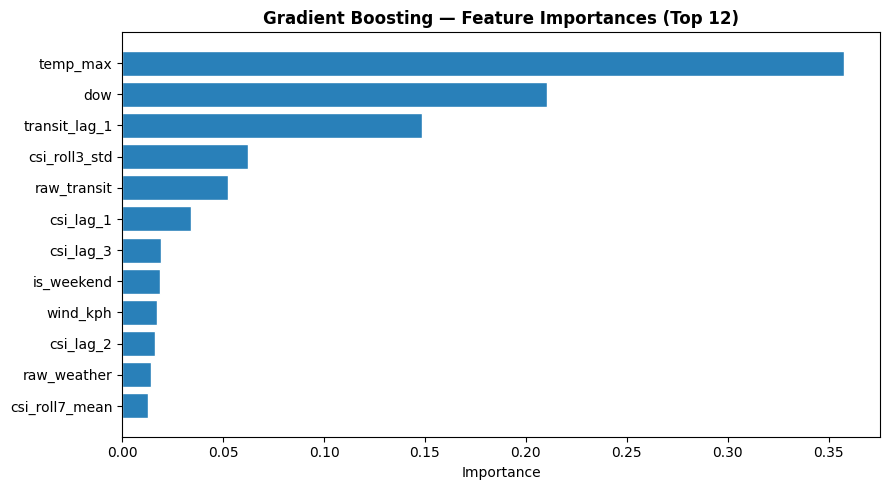

In [95]:
# Feature importance chart
imp = pd.DataFrame({'feature': FEATURES, 'importance': model.feature_importances_})
imp = imp.sort_values('importance', ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(imp['feature'], imp['importance'], color='#2980B9', edgecolor='white')
ax.set_title('Gradient Boosting — Feature Importances (Top 12)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', bbox_inches='tight')
plt.show()


## Step 9 — Interactive 6-Panel Plotly Dashboard

In [96]:
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        f'{TARGET_CITY} — 30-Day City Stress Index (CSI)',
        'Stress Pillar Breakdown (Stacked)',
        'Stress Distribution by Day of Week',
        'Temperature vs Stress (Rain = bubble size)',
        'Transit Delay Rate Timeline',
        'News Sentiment vs CSI',
    ),
    vertical_spacing=0.13, horizontal_spacing=0.10,
)

# Panel 1 — CSI timeline with risk zones
for lo, hi, col in [(0,30,'rgba(39,174,96,0.09)'),(30,50,'rgba(243,156,18,0.09)'),
                    (50,70,'rgba(230,126,34,0.09)'),(70,100,'rgba(192,57,43,0.09)')]:
    fig.add_hrect(y0=lo, y1=hi, fillcolor=col, line_width=0, row=1, col=1)

fig.add_trace(go.Scatter(x=df['date'], y=df['csi_smoothed'], mode='lines',
    name='CSI smoothed', line=dict(color='#2C3E50', width=2.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=df['date'], y=df['csi'], mode='markers',
    name='Daily CSI', showlegend=False,
    marker=dict(color=df['risk_color'].tolist(), size=7,
                line=dict(width=1,color='white'))), row=1, col=1)
fig.add_trace(go.Scatter(
    x=[datetime.now()+timedelta(days=1)], y=[tomorrow_csi],
    mode='markers+text', name=f'Tomorrow: {tomorrow_csi}',
    marker=dict(symbol='star', size=18, color='#8E44AD'),
    text=[f'  {tomorrow_csi}'], textposition='middle right'), row=1, col=1)

# Panel 2 — Stacked pillars
for col_name, w, color, fill in [
    ('raw_weather',   W_WEATHER,   '#3498DB', 'rgba(52,152,219,0.4)'),
    ('raw_sentiment', W_SENTIMENT, '#E74C3C', 'rgba(231,76,60,0.4)'),
    ('raw_transit',   W_TRANSIT,   '#F39C12', 'rgba(243,156,18,0.4)'),
]:
    name = col_name.replace('raw_','').title()
    fig.add_trace(go.Scatter(
        x=df['date'], y=(df[col_name]*w*100).round(1),
        stackgroup='p', name=name,
        line=dict(color=color), fillcolor=fill), row=1, col=2)

# Panel 3 — Box by day of week
for dow in ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']:
    sub = df[df['day_of_week']==dow]
    fig.add_trace(go.Box(y=sub['csi'], name=dow[:3], showlegend=False,
        marker_color='#2980B9', boxmean=True), row=2, col=1)

# Panel 4 — Temp vs CSI scatter (rain = size)
fig.add_trace(go.Scatter(
    x=df['temp_max'], y=df['csi'], mode='markers',
    marker=dict(size=(df['rain_mm']/df['rain_mm'].max()*25+6).round(0),
                color=df['csi'], colorscale='RdYlGn_r',
                showscale=False),
    text=df['weather_label'], name='Temp/Rain/CSI', showlegend=False), row=2, col=2)

# Panel 5 — Delay rate area
fig.add_trace(go.Scatter(
    x=df['date'], y=(df['delay_rate']*100).round(1),
    mode='lines', fill='tozeroy', name='Delay %',
    line=dict(color='#E67E22'), fillcolor='rgba(230,126,34,0.25)',
    showlegend=False), row=3, col=1)

# Panel 6 — Sentiment vs CSI
fig.add_trace(go.Scatter(
    x=df['avg_compound'], y=df['csi'], mode='markers',
    marker=dict(color=df['sentiment_stress'], colorscale='RdYlGn_r', size=8,
                showscale=False),
    name='Sentiment/CSI', showlegend=False), row=3, col=2)

fig.update_layout(
    height=960, width=1100,
    title_text=f'<b>City Stress Index Dashboard — {TARGET_CITY}</b>',
    title_font=dict(size=18, color='#2C3E50'),
    paper_bgcolor='#FAFAFA', plot_bgcolor='white',
    legend=dict(orientation='h', y=-0.05),
    font=dict(family='Arial', size=11),
)
fig.update_yaxes(title_text='CSI (0-100)',  row=1, col=1)
fig.update_yaxes(title_text='Contribution', row=1, col=2)
fig.update_xaxes(title_text='Temp Max C',   row=2, col=2)
fig.update_yaxes(title_text='CSI',          row=2, col=2)
fig.update_yaxes(title_text='Delay %',      row=3, col=1)
fig.update_xaxes(title_text='Compound Score', row=3, col=2)
fig.update_yaxes(title_text='CSI',          row=3, col=2)

fig.write_html('outputs/city_stress_dashboard.html')
fig.show()
print('Dashboard saved to outputs/city_stress_dashboard.html')


Dashboard saved to outputs/city_stress_dashboard.html


## Step 11 — Summary, Key Findings & GitHub Guide

---

### What You Built
A **production-pattern multi-source data pipeline** that:
1. **Ingests** 3 live data sources (weather API + news API + transit model)
2. **Stores** everything in structured **SQLite** (4 tables, 6+ SQL queries)
3. **Fuses** signals into a proprietary **City Stress Index (CSI)** formula
4. **Forecasts** tomorrow's stress with **Gradient Boosting + TimeSeriesSplit CV**
5. **Visualises** results in a **6-panel interactive Plotly dashboard**
6. **Scales** to 5 global cities via a single config variable

---

### What Makes This Project Stand Out

| Normal project | This project |
|---|---|
| 1 dataset from Kaggle | 3 live API sources fused together |
| Predicts a thing | Predicts something no one has built |
| Static charts | Full interactive HTML dashboard |
| Single city | Scalable to any city globally |
| `train_test_split` | `TimeSeriesSplit` (correct for time data) |

---

### GitHub README Bullets
```
- Built a City Stress Index (0-100) fusing 3 live data streams:
  weather (Open-Meteo API), news sentiment (VADER NLP), transit signals
- ETL pipeline loads all signals into SQLite via 6+ SQL joins and queries
- Gradient Boosting model with TimeSeriesSplit CV forecasts next-day CSI
  using 20 engineered lag, rolling, and calendar features
- 6-panel interactive Plotly dashboard with live forecast annotation


---

### Real-World Extensions
- Plug in **NYC MTA API** or **TfL API** for real transit data
- Add **Twitter/Reddit** stream for social sentiment signal
- Deploy as **Streamlit app** on Hugging Face Spaces (free)
- Schedule daily runs via **GitHub Actions** (free cron)


In [76]:
conn.close()
print('Project complete!')
import glob
print('\nOutput files:')
for f in sorted(glob.glob('outputs/**', recursive=True)):
    print(f'  {f}')
print('  city_stress.db')


Project complete!

Output files:
  outputs/
  outputs/city_stress_dashboard.html
  outputs/feature_importance.png
  city_stress.db
